In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

In [3]:
#Split into training set/test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Scale the data set accordingly
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Initialize model for LogisticRegression
iris_lr = LogisticRegression()
iris_lr.fit(X_train, y_train)


LogisticRegression()

In [5]:
#Predict the data with test set
y_pred = iris_lr.predict(X_test)

#Gather all the metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred)

#Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Kappa Score: {kappa:.2f}")

print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1 Score: 0.93
Kappa Score: 0.90
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


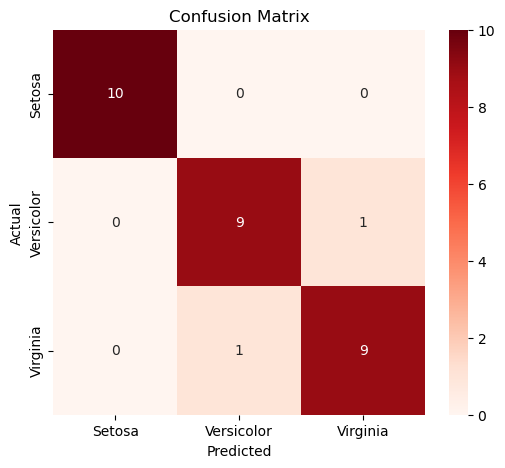

In [12]:
# Confusion matrix heat map
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Setosa", "Versicolor", "Virginia"], yticklabels=["Setosa", "Versicolor", "Virginia"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
# Perform cross-validation
cv_scores = cross_val_score(iris_lr, X, y, cv=10, scoring="accuracy")

# Print results
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.2f}")
print(f"Standard Deviation: {cv_scores.std():.2f}")

Cross-Validation Scores: [1.         0.93333333 1.         1.         0.93333333 0.93333333
 0.93333333 1.         1.         1.        ]
Mean Accuracy: 0.97
Standard Deviation: 0.03


c:\Users\wilso\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\wilso\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

The cross validation will have a different score as it take the whole data set I believe. With our original testing, we split the full data set into a training and testing set which means it will differ slightly. 

In [15]:
# Define hyperparameter grid
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}

# Perform grid search with cross-validation
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring="accuracy",verbose=3)
grid_search.fit(X_train, y_train)

# Best parameters and score
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ...........................C=0.001;, score=0.833 total time=   0.0s
[CV 2/5] END ...........................C=0.001;, score=0.833 total time=   0.0s
[CV 3/5] END ...........................C=0.001;, score=0.875 total time=   0.0s
[CV 4/5] END ...........................C=0.001;, score=0.833 total time=   0.0s
[CV 5/5] END ...........................C=0.001;, score=0.792 total time=   0.0s
[CV 1/5] END ............................C=0.01;, score=0.917 total time=   0.0s
[CV 2/5] END ............................C=0.01;, score=0.875 total time=   0.0s
[CV 3/5] END ............................C=0.01;, score=0.917 total time=   0.0s
[CV 4/5] END ............................C=0.01;, score=0.875 total time=   0.0s
[CV 5/5] END ............................C=0.01;, score=0.833 total time=   0.0s
[CV 1/5] END .............................C=0.1;, score=0.917 total time=   0.0s
[CV 2/5] END .............................C=0.1;,

The best Hyperparameter/C was 10 but it was also equal to the C of 100. I think that C adjusts the coefficient of how the score is calculated. So a larger C is probably a higher penaly for the score while a lower C is a lower penalty for the score.